# Polynomial Regression — Projectile Position Prediction

Predict the **y** position of a projectile from noisy **x** measurements using OLS polynomial regression (degree 2 and 20) and Lasso regression.

## 0. Import

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

np.random.seed(42)

## 1. Data Generation

In [76]:
def dataSimulate():
    x0, y0 = 0, 2
    theta0_rad = np.deg2rad(50)
    v0, g = 10, 9.81
    t = np.arange(0, 10, 0.01)

    xr = x0 + v0 * np.cos(theta0_rad) * t
    yr = y0 + v0 * np.sin(theta0_rad) * t - g * t**2 / 2

    mask = yr >= 0
    xr, yr = xr[mask], yr[mask]

    x_noisy = xr + np.random.normal(0, 0.5, size=xr.shape)
    y_noisy = yr + np.random.normal(0, 0.5, size=yr.shape)
    print(f"len(x_noisy): {len(x_noisy)}")
    return x_noisy, y_noisy


x_noisy, y_noisy = dataSimulate()
print(f"X_train: {x_noisy[len(x_noisy)-2:]}")
print(f"X_train: {x_noisy[len(x_noisy)-2:]*0.3+x_noisy[len(x_noisy)-2:]}")



len(x_noisy): 179
X_train: [11.66835397 11.57184058]
X_train: [15.16886017 15.04339276]


## 2. Train/Test Split (80% train, 20% test)

In [ ]:
def splitData(x_noisy, y_noisy):
    X_train, X_test, y_train, y_test = train_test_split(x_noisy, y_noisy, test_size=0.2, random_state=1)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = splitData(x_noisy, y_noisy)


X_train: [8.41414232 2.70276078]


## 3. Functions

In [55]:
def matriceA(X_train, X_test, degree):
    poly = PolynomialFeatures(degree)
    A_train = poly.fit_transform(X_train.reshape(-1, 1))
    A_test  = poly.transform(X_test.reshape(-1, 1))
    return A_train, A_test

def scaleFunction(A_train, A_test, y_train, y_test):
    scaler_A = StandardScaler()
    A_train_scaled = scaler_A.fit_transform(A_train)
    A_test_scaled  = scaler_A.transform(A_test)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
    return A_train_scaled, A_test_scaled, y_train_scaled, y_test_scaled

def OlspreditY(A_train_scaled, A_test_scaled, y_train_scaled):
    OLS_reg = LinearRegression().fit(A_train_scaled, y_train_scaled)
    y_Pred_OLS = OLS_reg.predict(A_test_scaled)
    return y_Pred_OLS

def lassoPreditY(A_train_scaled, A_test_scaled, y_train_scaled, alpha):
    lasso_reg = Lasso(alpha=alpha, max_iter=100000).fit(A_train_scaled, y_train_scaled)
    y_Pred_Lasso = lasso_reg.predict(A_test_scaled)
    return y_Pred_Lasso

def lassoCvPreditY(A_train_scaled, A_test_scaled, y_train_scaled, cv):
    lassoCV_reg = LassoCV(cv=cv, max_iter=100000, random_state=42).fit(A_train_scaled, y_train_scaled)
    y_Pred_LassoCV = lassoCV_reg.predict(A_test_scaled)
    return y_Pred_LassoCV, lassoCV_reg.alpha_

def ridgePreditY(A_train_scaled, A_test_scaled, y_train_scaled, alpha):
    ridge_reg = Ridge(alpha=alpha).fit(A_train_scaled, y_train_scaled)
    y_Pred_Ridge = ridge_reg.predict(A_test_scaled)
    return y_Pred_Ridge

def ridgeCvPreditY(A_train_scaled, A_test_scaled, y_train_scaled, alphas, cv):
    ridge_reg = RidgeCV(alphas=alphas, cv=cv).fit(A_train_scaled, y_train_scaled)
    y_Pred_Ridge = ridge_reg.predict(A_test_scaled)
    return y_Pred_Ridge, ridge_reg.alpha_

## 4. OLS Regression — Polynomial Degree 2

In [56]:
A_train, A_test = matriceA(X_train, X_test, degree=2)
A_train_sc, A_test_sc, y_train_sc, y_test_sc = scaleFunction(A_train, A_test, y_train, y_test)
y_pred_2 = OlspreditY(A_train_sc, A_test_sc, y_train_sc)
r2_2 = r2_score(y_test_sc, y_pred_2)
print(f"OLS Degree 2  — R2: {r2_2:.4f}")

OLS Degree 2  — R2: 0.7872


## 5. OLS Regression — Polynomial Degree 20

In [93]:
A_train_20, A_test_20 = matriceA(X_train, X_test, degree=20)
A_train_sc_20, A_test_sc_20, y_train_sc_20, y_test_sc_20 = scaleFunction(A_train_20, A_test_20, y_train, y_test)
y_pred_20 = OlspreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20)
r2_20 = r2_score(y_test_sc_20, y_pred_20)
print(f"OLS Degree 20 — R2: {r2_20:.4f}")

OLS Degree 20 — R2: 0.7313


## OLS Degré 2 vs OLS Degré 20
OLS avec 2 degrés est meilleur qu'OLS degré 20 en raison de l'overfitting. C'est-à-dire que le modèle avec 20 degrés épouse tellement les données d'entraînement, et donc aussi le bruit de celles-ci, ce qui le conduit à être moins performant pour prédire avec les variables test.

## 6. Lasso Regression — Polynomial Degree 20

Same degree-20 polynomial features and scaling as above. We test different values of `alpha` to observe the regularization effect.

In [87]:
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    y_pred_lasso_20 = lassoPreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, alpha)
    r2_lasso_20 = r2_score(y_test_sc_20, y_pred_lasso_20)
    print(f"Lasso Degree 20 (alpha={alpha}) — R2: {r2_lasso_20:.4f}")

Lasso Degree 20 (alpha=0.001) — R2: 0.8058
Lasso Degree 20 (alpha=0.01) — R2: 0.7928
Lasso Degree 20 (alpha=0.1) — R2: 0.3426
Lasso Degree 20 (alpha=1.0) — R2: -0.1327
Lasso Degree 20 (alpha=10.0) — R2: -0.1327
Lasso Degree 20 (alpha=100.0) — R2: -0.1327


## 8.Lasso Regression Cross-Validation 

In [88]:
y_pred_lassoCV_20, best_alpha_lasso = lassoCvPreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, 30)
r2_lassoCV_20 = r2_score(y_test_sc_20, y_pred_lassoCV_20)
print(f"LassoCV Degree 20 — Best alpha: {best_alpha_lasso:.6f}")
print(f"LassoCV Degree 20 — R2: {r2_lassoCV_20:.4f}")

LassoCV Degree 20 — Best alpha: 0.001504
LassoCV Degree 20 — R2: 0.8084


## Comparaison Lasso vs LassoCV

La cross-validation trouve un alpha plus précis que la recherche manuelle sur une grille grossière.

Avec cv=30, LassoCV atteint R²=0.8084, légèrement supérieur au meilleur résultat manuel (0.8058), car il explore une grille d'alphas bien plus dense et adaptée aux données. Si cv devient trop grand, les sous-ensembles deviennent petits et le résultat peut devenir moins stable.

En revanche, on peut remarquer qu'avec cv=5, la recherche manuelle obtient de meilleurs résultats que LassoCV.
Dans tous les cas, on voit que les deux méthodes Lasso améliorent le résultat d'OLS degré 20, car elles annulent les poids excessifs et surpassent même OLS degré 2.

## 9. Ridge Regression

In [94]:
for alpha in [0.001, 0.01, 0.1, 1.0,]:
    y_pred_ridge_20 = ridgePreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, alpha)
    r2_ridge_20 = r2_score(y_test_sc_20, y_pred_ridge_20)
    print(f"Ridge Degree 20 (alpha={alpha}) — R2: {r2_ridge_20:.4f}")

Ridge Degree 20 (alpha=0.001) — R2: 0.7529
Ridge Degree 20 (alpha=0.01) — R2: 0.7521
Ridge Degree 20 (alpha=0.1) — R2: 0.7497
Ridge Degree 20 (alpha=1.0) — R2: 0.7244


## 10. Ridge Regression Cross-Validation

In [112]:
alphas = np.logspace(-4, 2, 1000)
y_pred_RidgeCV_20, best_alpha_ridge = ridgeCvPreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, alphas, cv=5)
r2_RidgeCV_20 = r2_score(y_test_sc_20, y_pred_RidgeCV_20)
print(f"RidgeCV Degree 20 — Best alpha: {best_alpha_ridge:.6f}")
print(f"RidgeCV Degree 20 — R2: {r2_RidgeCV_20:.4f}")

RidgeCV Degree 20 — Best alpha: 0.000556
RidgeCV Degree 20 — R2: 0.7537


## Ridge vs RidgeCV
En testant davantage de valeurs de α, RidgeCV devient légèrement meilleur que Ridge, mais il est aussi plus long à exécuter.

À partir de cv=6, la valeur de R² diminue légèrement, probablement parce que les folds deviennent trop petits, ce qui rend le choix de α plus sensible au bruit.

## Ridge vs OLS
Le résultat est plus contrasté : OLS degré 2 domine les trois autres, ensuite viennent les deux Ridge et enfin OLS degré 20. Nous pouvons conclure que Ridge arrive à limiter le bruit malgré les grands degrés et être plus performant qu'OLS degré 20, mais pas assez pour dépasser OLS degré 2.

## Ridge vs Lasso
Ridge reste inférieur à Lasso ici, probablement parce que Ridge ne peut pas annuler complètement les coefficients les moins utiles. Il les réduit seulement, alors que Lasso peut les ramener exactement à zéro. Dans un modèle de degré 20, cela permet à Lasso de mieux limiter l'effet des termes trop sensibles au bruit.

## 11. Lasso vs Ridge — Extrapolation (x étendu)

In [62]:
"""def dataSimulate():
    x0, y0 = 0, 2
    theta0_rad = np.deg2rad(50)
    v0, g = 10, 9.81
    t = np.arange(0, 10, 0.01)

    xr = x0 + v0 * np.cos(theta0_rad) * t
    yr = y0 + v0 * np.sin(theta0_rad) * t - g * t**2 / 2

    mask = yr >= 0
    xrCopy = xr.copy()  
    xr, yr = xr[mask], yr[mask]
    x_noisy = xr + np.random.normal(0, 0.5, size=xr.shape)
    y_noisy = yr + np.random.normal(0, 0.5, size=yr.shape)
    nbExtrapolation = round(len(xr) + 0.3*len(xr))
    xrExtrapolation = xrCopy[:nbExtrapolation]
    xrExtrNoisy = xrExtrapolation + np.random.normal(0, 0.5, size=xrExtrapolation.shape)
    scalarX = StandardScaler()
    xrExtrNoisyScaled = scalarX.transform(xrExtrNoisy)


    return x_noisy, y_noisy, xrExtrNoisyScaled
x_noisy, y_noisy, xrExtrNoisyScaled = dataSimulate()
print(f"Number of training points: {len(x_noisy)}")
print(f"Number of extrapolation points: {len(xrExtrNoisyScaled)}")

for alpha in [0.001, 0.01, 0.1, 1.0,0.000802,0.001504]:
    y_pred_lasso_20 = lassoPreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, alpha)
    r2_lasso_20 = r2_score(y_test_sc_20, y_pred_lasso_20)
    print(f"Lasso Degree 20 (alpha={alpha}) — R2: {r2_lasso_20:.4f}")

for alpha in [0.001, 0.01, 0.1, 1.0,0.000100]:
    y_pred_ridge_20 = ridgePreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, alpha)
    r2_ridge_20 = r2_score(y_test_sc_20, y_pred_ridge_20)
    print(f"Ridge Degree 20 (alpha={alpha}) — R2: {r2_ridge_20:.4f}")



"""

'def dataSimulate():\n    x0, y0 = 0, 2\n    theta0_rad = np.deg2rad(50)\n    v0, g = 10, 9.81\n    t = np.arange(0, 10, 0.01)\n\n    xr = x0 + v0 * np.cos(theta0_rad) * t\n    yr = y0 + v0 * np.sin(theta0_rad) * t - g * t**2 / 2\n\n    mask = yr >= 0\n    xrCopy = xr.copy()  \n    xr, yr = xr[mask], yr[mask]\n    x_noisy = xr + np.random.normal(0, 0.5, size=xr.shape)\n    y_noisy = yr + np.random.normal(0, 0.5, size=yr.shape)\n    nbExtrapolation = round(len(xr) + 0.3*len(xr))\n    xrExtrapolation = xrCopy[:nbExtrapolation]\n    xrExtrNoisy = xrExtrapolation + np.random.normal(0, 0.5, size=xrExtrapolation.shape)\n    scalarX = StandardScaler()\n    xrExtrNoisyScaled = scalarX.transform(xrExtrNoisy)\n\n\n    return x_noisy, y_noisy, xrExtrNoisyScaled\nx_noisy, y_noisy, xrExtrNoisyScaled = dataSimulate()\nprint(f"Number of training points: {len(x_noisy)}")\nprint(f"Number of extrapolation points: {len(xrExtrNoisyScaled)}")\n\nfor alpha in [0.001, 0.01, 0.1, 1.0,0.000802,0.001504]:\n    

## 11. BISS

x_extrap: [10.93838501  3.51358901]


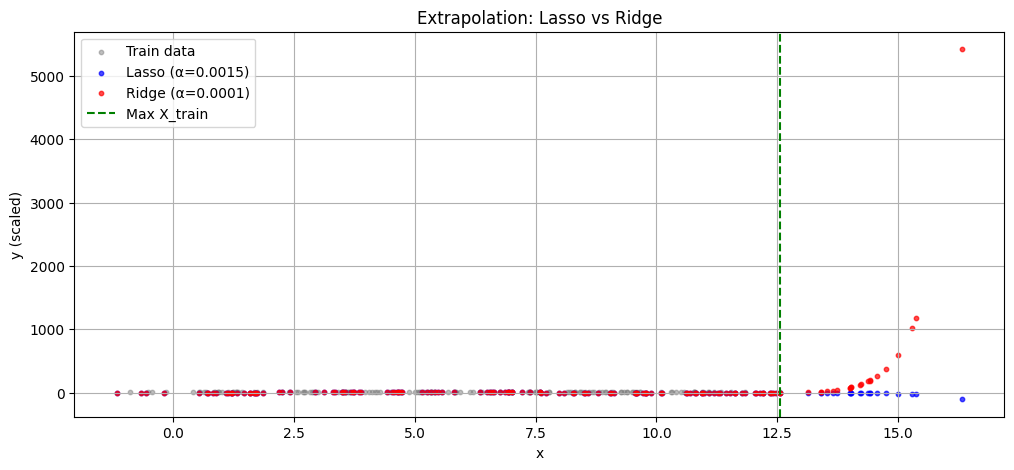

In [ ]:
x_extrap = X_train * 1.3

A_train, A_extrap_ext = matriceA(X_train, x_extrap, degree=20)
A_train_sc, A_extrap_sc_ext, y_train_sc, y_test_sc = scaleFunction(
    A_train, A_extrap_ext, y_train, y_test
)
##A_extrap_sc_ext  joue le role de A_test_scaled pour les données d'extrapolation
y_extrap_lasso = lassoPreditY(A_train_sc, A_extrap_sc_ext, y_train_sc, alpha=0.001504)
y_extrap_ridge = ridgePreditY(A_train_sc, A_extrap_sc_ext, y_train_sc, alpha=0.000100)

plt.figure(figsize=(12, 5))
plt.scatter(X_train, y_train, s=10, color='gray', label='Train data', alpha=0.5)
plt.scatter(x_extrap, y_extrap_lasso, s=10, color='blue', label=f'Lasso (α={0.001504:.4f})', alpha=0.7)
plt.scatter(x_extrap, y_extrap_ridge, s=10, color='red', label=f'Ridge (α={0.000100:.4f})', alpha=0.7)
plt.axvline(X_train.max(), color='green', linestyle='--', label='Max X_train')
plt.xlabel('x')
plt.ylabel('y (scaled)')
plt.title('Extrapolation: Lasso vs Ridge')
plt.legend()
plt.grid(True)
plt.show()

## Discussion — Point 11
Lasso est plus robuste en extrapolation que Ridge.

**Lasso** : met la plupart des coefficients à zéro, donc le modèle se réduit à quelques termes — la divergence est limitée hors de la plage d'entraînement.

**Ridge** : garde tous les coefficients actifs, ce qui conduit à ce que la somme des termes x², x³...x²⁰ explose dès qu'on sort de la zone d'entraînement.

## Conclusion
Le modèle OLS degré 2 est déjà bien adapté, car la trajectoire d’un projectile est naturellement quadratique. Au contraire, OLS degré 20 est trop complexe et surapprend davantage le bruit.

Les méthodes Lasso et Ridge améliorent donc le modèle de degré 20 grâce à la régularisation. 

Ici, Lasso donne les meilleurs résultats, car il peut annuler certains coefficients inutiles, tandis que Ridge les réduit seulement. 

Les versions CV permettent de choisir automatiquement α, mais ne donnent pas toujours le meilleur score sur le test final, cela depend du nombre de alpha et de cv choisi tout en prennat beaucoup plus de temps .